In [1]:
# ==========================================
# 1. Import thư viện
# ==========================================

import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms

from torch.utils.data import DataLoader
from torch.utils.data import random_split

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Import thành công!")

Import thành công!


In [2]:
# ==========================================
# 2. Kiểm tra GPU
# ==========================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [3]:
# ==========================================
# 3. Thiết lập Seed
# ==========================================

seed = 42

random.seed(seed)
np.random.seed(seed)

torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

print("Seed =", seed)

Seed = 42


In [4]:
# ==========================================
# 4. Download dữ liệu
# ==========================================

transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Train:", len(train_dataset))
print("Test :", len(test_dataset))

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 198kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.73MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.6MB/s]

Train: 60000
Test : 10000


In [5]:
# ==========================================
# 5. Danh sách lớp
# ==========================================

classes = train_dataset.classes

print(classes)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


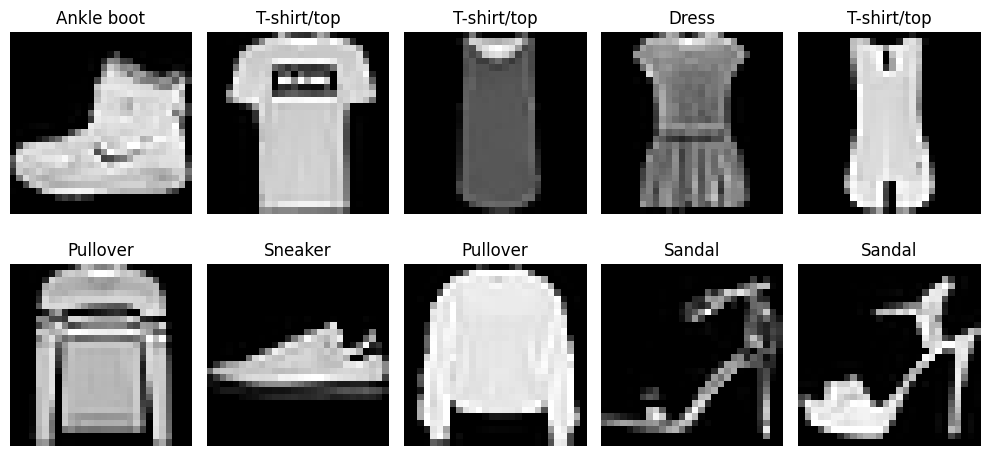

In [6]:
# ==========================================
# 6. Hiển thị ảnh mẫu
# ==========================================

plt.figure(figsize=(10,5))

for i in range(10):

    image, label = train_dataset[i]

    plt.subplot(2,5,i+1)

    plt.imshow(image.squeeze(), cmap="gray")

    plt.title(classes[label])

    plt.axis("off")

plt.tight_layout()

plt.show()

In [7]:
# ==========================================
# 7. Chia Train và Validation
# ==========================================

train_size = int(len(train_dataset) * 0.8)
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(
    train_dataset,
    [train_size, val_size]
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 48000
Validation: 12000
Test: 10000


In [8]:
# ==========================================
# 8. DataLoader
# ==========================================

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 1500
Validation batches: 375
Test batches: 313


In [9]:
# ==========================================
# 9. Neural Network
# ==========================================

class FashionMNISTModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Flatten(),

            nn.Linear(28 * 28, 512),
            nn.ReLU(),

            nn.Linear(512, 256),
            nn.ReLU(),

            nn.Linear(256, 10)

        )

    def forward(self, x):
        return self.model(x)

In [10]:
# ==========================================
# 10. Khởi tạo Model
# ==========================================

model = FashionMNISTModel().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model)

FashionMNISTModel(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [11]:
# ==========================================
# 11. Train Function
# ==========================================

def train_one_epoch():

    model.train()

    running_loss = 0

    correct = 0

    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        predicted = outputs.argmax(1)

        correct += (predicted == labels).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)

    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [12]:
# ==========================================
# 11. Train Function
# ==========================================

def train_one_epoch():

    model.train()

    running_loss = 0

    correct = 0

    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        predicted = outputs.argmax(1)

        correct += (predicted == labels).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)

    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [13]:
# ==========================================
# 12. Validation Function
# ==========================================

def validate():

    model.eval()

    running_loss = 0

    correct = 0

    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            predicted = outputs.argmax(1)

            correct += (predicted == labels).sum().item()

            total += labels.size(0)

    val_loss = running_loss / len(val_loader)

    val_acc = correct / total

    return val_loss, val_acc

In [14]:
# ==========================================
# 13. Khởi tạo lịch sử huấn luyện
# ==========================================

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

best_accuracy = 0

In [15]:
# ==========================================
# 14. Huấn luyện mô hình
# ==========================================

num_epochs = 10

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch()

    val_loss, val_acc = validate()

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    if val_acc > best_accuracy:

        best_accuracy = val_acc

        torch.save(model.state_dict(), "best_model.pth")

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

print("\nTraining Finished!")
print(f"Best Validation Accuracy: {best_accuracy:.4f}")

Epoch [1/10] | Train Loss: 0.5034 | Train Acc: 0.8169 | Val Loss: 0.4040 | Val Acc: 0.8556
Epoch [2/10] | Train Loss: 0.3693 | Train Acc: 0.8637 | Val Loss: 0.3626 | Val Acc: 0.8710
Epoch [3/10] | Train Loss: 0.3312 | Train Acc: 0.8775 | Val Loss: 0.3332 | Val Acc: 0.8808
Epoch [4/10] | Train Loss: 0.3043 | Train Acc: 0.8884 | Val Loss: 0.3583 | Val Acc: 0.8727
Epoch [5/10] | Train Loss: 0.2860 | Train Acc: 0.8925 | Val Loss: 0.3510 | Val Acc: 0.8688
Epoch [6/10] | Train Loss: 0.2708 | Train Acc: 0.8977 | Val Loss: 0.3299 | Val Acc: 0.8820
Epoch [7/10] | Train Loss: 0.2553 | Train Acc: 0.9029 | Val Loss: 0.3314 | Val Acc: 0.8832
Epoch [8/10] | Train Loss: 0.2451 | Train Acc: 0.9060 | Val Loss: 0.3226 | Val Acc: 0.8900
Epoch [9/10] | Train Loss: 0.2321 | Train Acc: 0.9119 | Val Loss: 0.3167 | Val Acc: 0.8888
Epoch [10/10] | Train Loss: 0.2224 | Train Acc: 0.9164 | Val Loss: 0.3206 | Val Acc: 0.8912

Training Finished!
Best Validation Accuracy: 0.8912


In [16]:
# ==========================================
# 15. Load Best Model
# ==========================================

model.load_state_dict(torch.load("best_model.pth"))

print("Best model loaded successfully!")

Best model loaded successfully!


In [17]:
# ==========================================
# 16. Đánh giá trên Test
# ==========================================

model.eval()

test_loss = 0

correct = 0

total = 0

all_predictions = []

all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        test_loss += loss.item()

        predicted = outputs.argmax(1)

        correct += (predicted == labels).sum().item()

        total += labels.size(0)

        all_predictions.extend(predicted.cpu().numpy())

        all_labels.extend(labels.cpu().numpy())

test_loss /= len(test_loader)

test_accuracy = correct / total

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

Test Loss     : 0.3492
Test Accuracy : 0.8815


In [18]:
# ==========================================
# 17. Classification Report
# ==========================================

print(classification_report(
    all_labels,
    all_predictions,
    target_names=classes
))

              precision    recall  f1-score   support

 T-shirt/top       0.86      0.80      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.81      0.77      0.79      1000
       Dress       0.88      0.90      0.89      1000
        Coat       0.82      0.77      0.79      1000
      Sandal       0.99      0.93      0.96      1000
       Shirt       0.66      0.76      0.70      1000
     Sneaker       0.93      0.97      0.95      1000
         Bag       0.96      0.98      0.97      1000
  Ankle boot       0.95      0.96      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



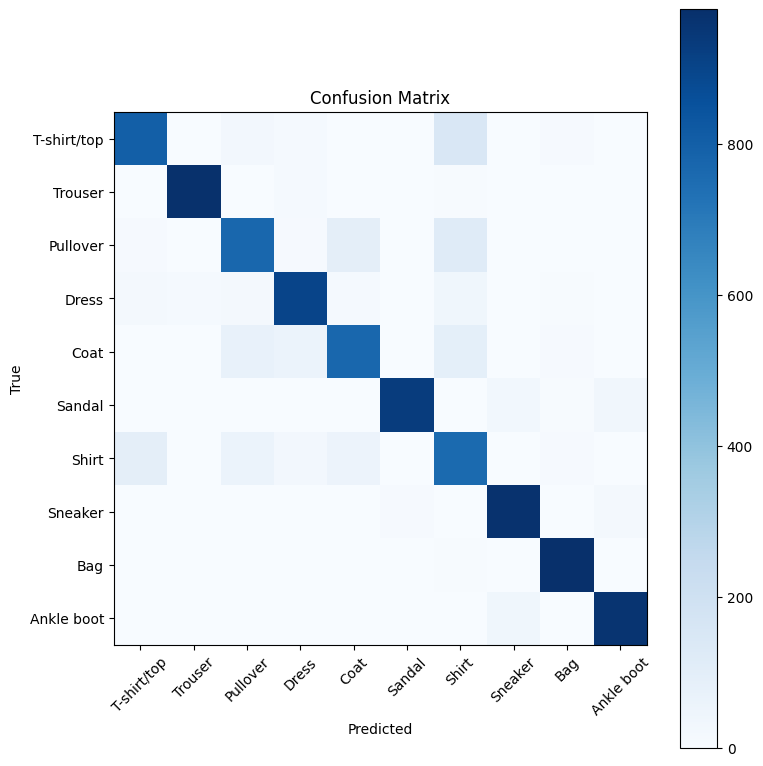

In [19]:
# ==========================================
# 18. Confusion Matrix
# ==========================================

cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(8,8))

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks(range(10), classes, rotation=45)

plt.yticks(range(10), classes)

plt.xlabel("Predicted")

plt.ylabel("True")

plt.tight_layout()

plt.show()

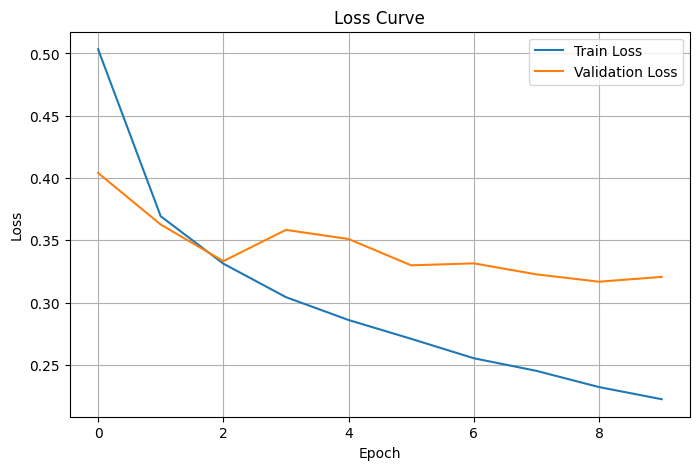

In [20]:
# ==========================================
# 19. Loss Curve
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")

plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss Curve")

plt.legend()

plt.grid(True)

plt.show()

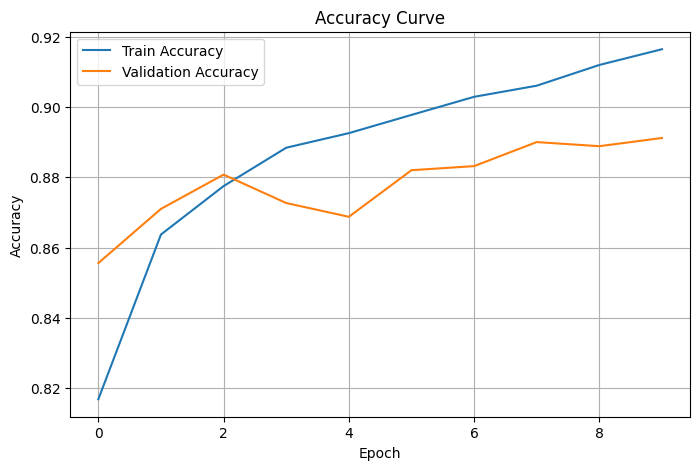

In [21]:
# ==========================================
# 20. Accuracy Curve
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label="Train Accuracy")

plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Accuracy Curve")

plt.legend()

plt.grid(True)

plt.show()

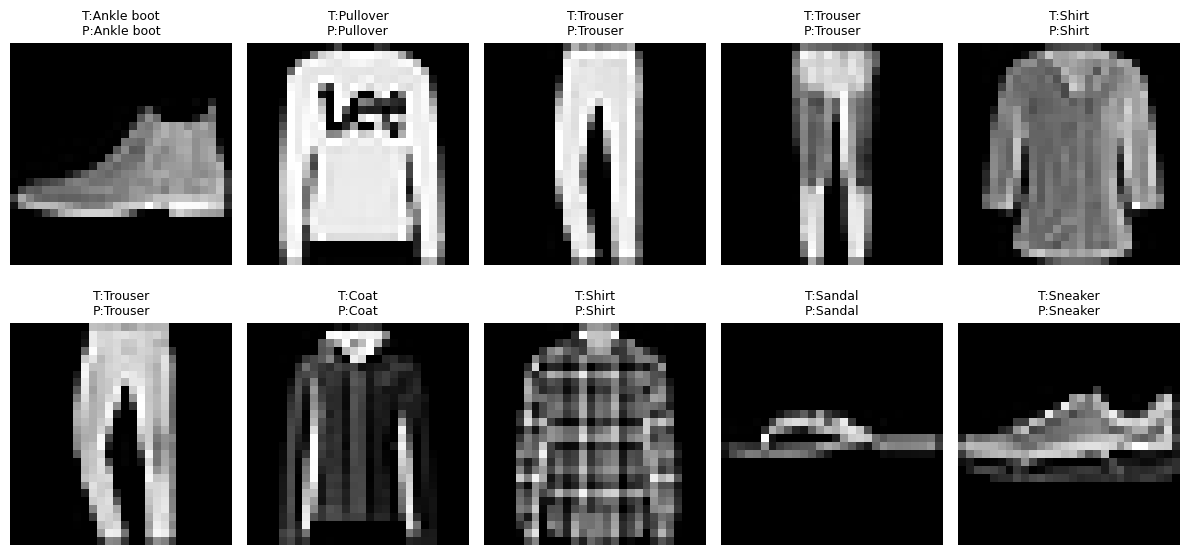

In [22]:
# ==========================================
# 21. Dự đoán ảnh
# ==========================================

model.eval()

plt.figure(figsize=(12,6))

for i in range(10):

    image, label = test_dataset[i]

    image_input = image.unsqueeze(0).to(device)

    with torch.no_grad():

        prediction = model(image_input)

        predicted_label = prediction.argmax(1).item()

    plt.subplot(2,5,i+1)

    plt.imshow(image.squeeze(), cmap="gray")

    plt.title(
        f"T:{classes[label]}\nP:{classes[predicted_label]}",
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()

plt.show()